<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Drashti Ruparelia</b></center>
    
<center><b><h1>Lab - 4</b></center>    
<pre>    

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [37]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sb

## Step 2. Import the dataset

In [3]:
df=pd.read_csv("50_Startups.csv")

In [5]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


## Step 3 . Check the State Column

In [9]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [13]:
x=df.iloc[::,:4:]
y=df.iloc[::,4::]
x

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [17]:
x1=pd.get_dummies(x,columns=['State'],drop_first=True)
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [17]:
# Already Performed using | drop_first =True

## Step 7 Splitting dataset in to Train and Test

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x1,y,train_size=0.8)

## Step 8  Import LinearRegression model from linear_model family 

In [23]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

## Step 9  Fit the data

In [41]:
model.fit(x_train,y_train)

LinearRegression()

## Step 10  Predict the data

In [43]:
y_predict=model.predict(x_test)

## Step 11  Display Result

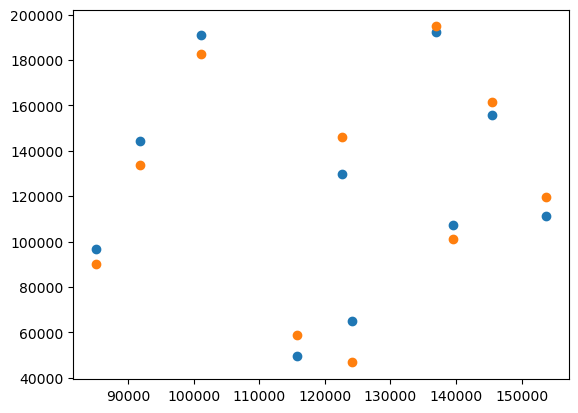

In [45]:
# y_test and y_predict
plt.scatter(x_test['Administration'],y_test)
plt.scatter(x_test['Administration'],y_predict)

## RSS

In [47]:
np.sum((y_test.values-y_predict)**2)

1062435311.5625174

In [49]:
len(y_test)

10

In [53]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test.values,y_predict)*len(y_predict)

1062435311.5625174

In [55]:
len(y_predict)

10

## R Square

In [57]:
from sklearn.metrics import r2_score

In [59]:
r2_score(y_test,y_predict)

0.9490277557129277

## Now use Polynomial Regression on Position_Salaries dataset

In [61]:
df=pd.read_csv("Position_Salaries.csv")

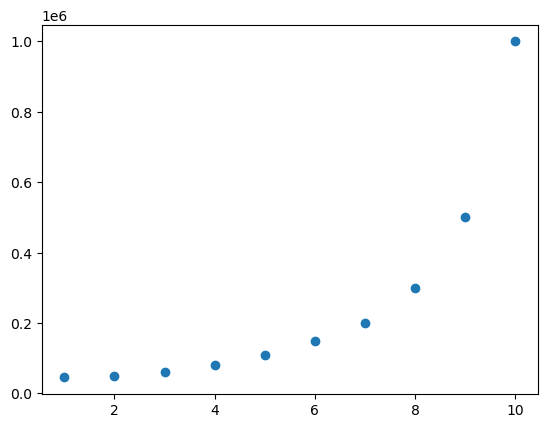

In [63]:
plt.scatter(df['Level'],df['Salary'])

In [65]:
x=df.iloc[::,1:2:]
y=df['Salary']
x

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [73]:
y

0      45000
1      50000
2      60000
3      80000
4     110000
5     150000
6     200000
7     300000
8     500000
9    1000000
Name: Salary, dtype: int64

In [75]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=7)
x_train

,Level
2,3
1,2
9,10
7,8
3,4
6,7
4,5


In [81]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x1=poly.fit_transform(x_train)
x1

array([[  1.,   3.,   9.],
       [  1.,   2.,   4.],
       [  1.,  10., 100.],
       [  1.,   8.,  64.],
       [  1.,   4.,  16.],
       [  1.,   7.,  49.],
       [  1.,   5.,  25.]])

In [83]:
model1=LinearRegression()

In [85]:
model1.fit(x1,y_train)

LinearRegression()

In [87]:
y_poly_predict=model1.predict(poly.fit_transform(x_test))
y_poly_predict

array([649837.66233766, 113068.18181818, 248647.18614719])

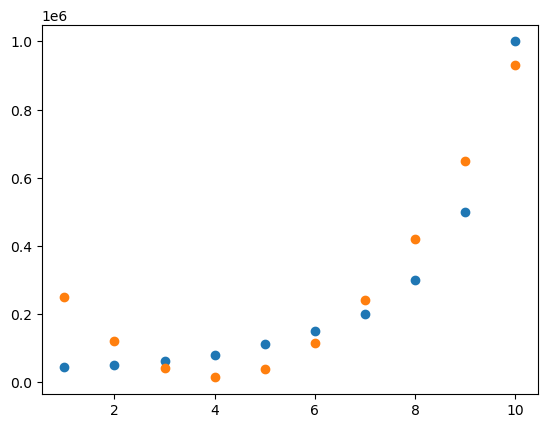

In [89]:
plt.scatter(df['Level'],df['Salary'])
plt.scatter(df['Level'],model1.predict(poly.fit_transform(x)))

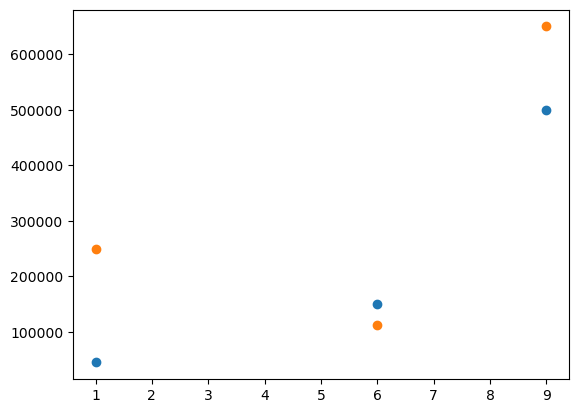

In [91]:
plt.scatter(x_test,y_test)
plt.scatter(x_test,y_poly_predict)